# 04 — Anomaly Detection
**Citi Bike Demand Forecasting & A/B Testing Framework**

Goals:
1. Z-score flagging — rolling window per station
2. IQR flagging — per station × hour-of-day slot
3. Isolation Forest — multivariate, system-wide
4. Compare methods and inspect flagged events
5. Save anomaly labels → used to clean data before A/B simulation in Phase 5

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from src.models.anomaly import (
    zscore_anomalies,
    iqr_anomalies,
    build_if_features,
    fit_isolation_forest,
    IF_FEATURE_COLS,
)

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

PROCESSED_DIR = Path('../data/processed')

## 1. Load Data

In [2]:
hourly = pd.read_parquet(PROCESSED_DIR / 'hourly_demand_2024Q1.parquet')
clusters = pd.read_parquet(PROCESSED_DIR / 'station_clusters.parquet').set_index('station_id')

print(f'Hourly rows: {len(hourly):,} | Stations: {hourly["station_id"].nunique():,}')
hourly.head(3)

Hourly rows: 1,963,864 | Stations: 2,269


,station_id,hour,trip_count,member_trips,casual_trips,classic_trips,electric_trips,lat,lng,hour_of_day,day_of_week,month,is_weekend
0,190 Morgan,2024-02-23 12:00:00,1,1,0,0,1,40.711072,-73.932096,12,4,2,0
1,2733.03,2024-01-01 14:00:00,3,0,3,0,3,40.633385,-74.016562,14,0,1,0
2,2733.03,2024-01-01 16:00:00,5,5,0,1,4,40.633385,-74.016562,16,0,1,0


## 2. Z-Score Flagging

In [3]:
df_z = zscore_anomalies(hourly, window=168, threshold=3.0)

n_anomalies = df_z['zscore_anomaly'].sum()
pct = n_anomalies / len(df_z) * 100
print(f'Z-score anomalies: {n_anomalies:,} / {len(df_z):,} rows ({pct:.2f}%)')
print(f'Stations with at least one anomaly: {df_z[df_z["zscore_anomaly"]]["station_id"].nunique():,}')

Z-score anomalies: 37,340 / 1,963,864 rows (1.90%)
Stations with at least one anomaly: 2,220


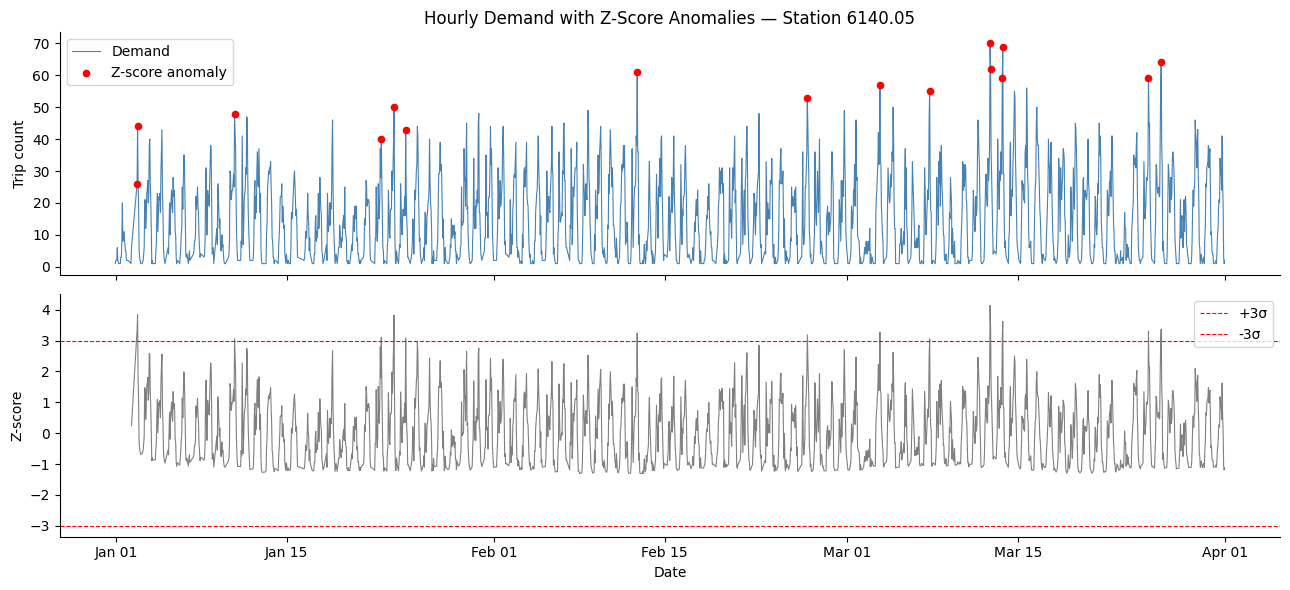

In [4]:
# Plot: demand time series for a busy station with anomalies highlighted
station_totals = hourly.groupby('station_id')['trip_count'].sum()
demo_sid = station_totals.idxmax()

s = df_z[df_z['station_id'] == demo_sid].set_index('hour').sort_index()
anomaly_pts = s[s['zscore_anomaly']]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(s.index, s['trip_count'], linewidth=0.8, color='steelblue', label='Demand')
axes[0].scatter(anomaly_pts.index, anomaly_pts['trip_count'],
                color='red', s=20, zorder=5, label='Z-score anomaly')
axes[0].set_title(f'Hourly Demand with Z-Score Anomalies — Station {demo_sid}')
axes[0].set_ylabel('Trip count')
axes[0].legend()

axes[1].plot(s.index, s['zscore'], linewidth=0.8, color='gray')
axes[1].axhline(3,  color='red',  linestyle='--', linewidth=0.8, label='+3σ')
axes[1].axhline(-3, color='red',  linestyle='--', linewidth=0.8, label='-3σ')
axes[1].set_ylabel('Z-score')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

## 3. IQR Flagging

In [5]:
df_iqr = iqr_anomalies(hourly, multiplier=3.0)

n_iqr = df_iqr['iqr_anomaly'].sum()
pct_iqr = n_iqr / len(df_iqr) * 100
print(f'IQR anomalies: {n_iqr:,} / {len(df_iqr):,} rows ({pct_iqr:.2f}%)')
print(f'Stations with at least one anomaly: {df_iqr[df_iqr["iqr_anomaly"]]["station_id"].nunique():,}')

IQR anomalies: 45,976 / 1,963,864 rows (2.34%)
Stations with at least one anomaly: 2,222


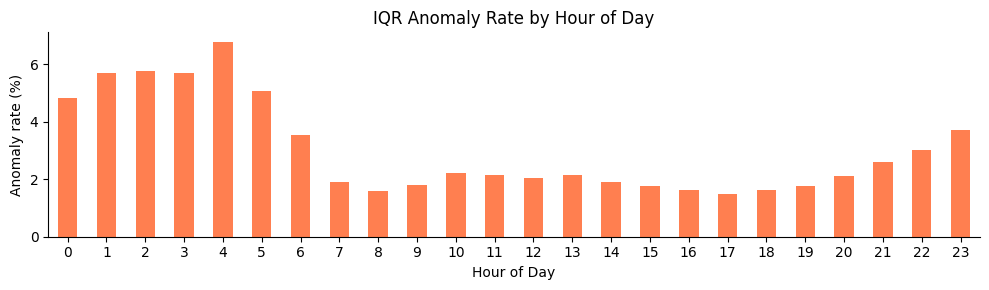

In [6]:
# Anomaly rate by hour of day — are certain hours more anomalous?
anomaly_by_hour = df_iqr.groupby('hour_of_day')['iqr_anomaly'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 3))
anomaly_by_hour.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_title('IQR Anomaly Rate by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Anomaly rate (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

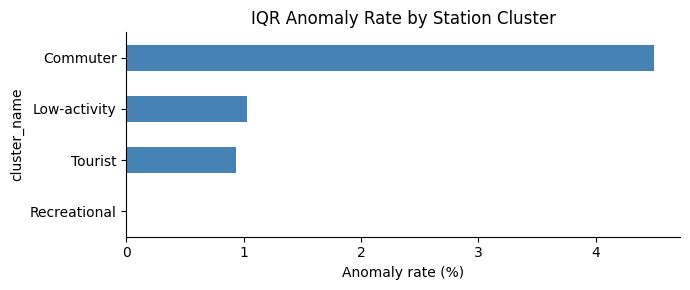

In [7]:
# Anomaly rate by cluster
df_iqr_c = df_iqr.merge(
    clusters[['kmeans_cluster', 'cluster_name']].reset_index(),
    on='station_id', how='left'
)
anomaly_by_cluster = df_iqr_c.groupby('cluster_name')['iqr_anomaly'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 3))
anomaly_by_cluster.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('IQR Anomaly Rate by Station Cluster')
ax.set_xlabel('Anomaly rate (%)')
plt.tight_layout()
plt.show()

## 4. Isolation Forest

In [8]:
df_if_input = build_if_features(hourly)
print(f'IF feature matrix: {df_if_input.shape}')

if_model, if_scaler, df_if = fit_isolation_forest(df_if_input, contamination=0.01)

n_if = df_if['if_anomaly'].sum()
print(f'Isolation Forest anomalies: {n_if:,} / {len(df_if):,} ({n_if/len(df_if)*100:.2f}%)')

IF feature matrix: (1597886, 17)
Isolation Forest anomalies: 15,979 / 1,597,886 (1.00%)


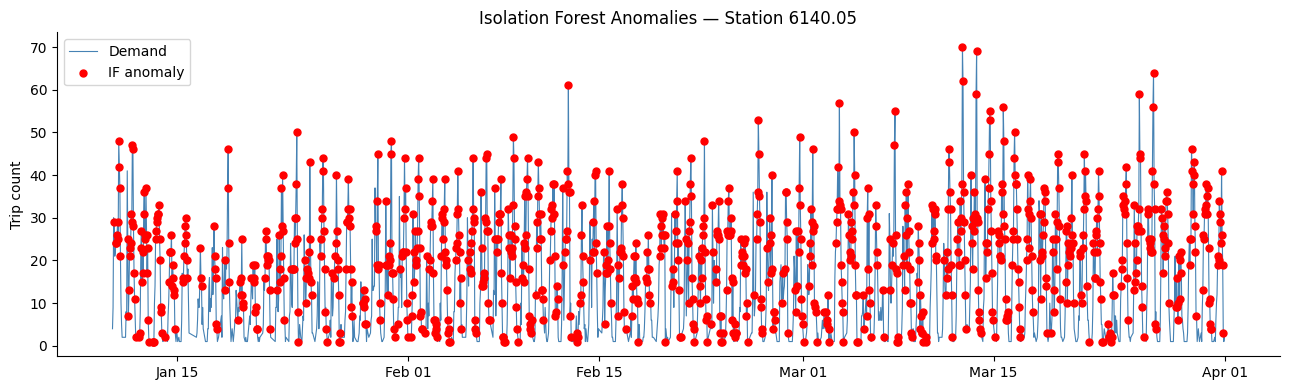

In [9]:
# Plot IF anomalies for the busiest station
s_if = df_if[df_if['station_id'] == demo_sid].set_index('hour').sort_index()
if_pts = s_if[s_if['if_anomaly']]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s_if.index, s_if['trip_count'], linewidth=0.8, color='steelblue', label='Demand')
ax.scatter(if_pts.index, if_pts['trip_count'],
           color='red', s=25, zorder=5, label='IF anomaly')
ax.set_title(f'Isolation Forest Anomalies — Station {demo_sid}')
ax.set_ylabel('Trip count')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

## 5. Method Comparison

In [10]:
# Combine all flags onto a common index (inner join on station_id + hour)
base = hourly[['station_id', 'hour', 'trip_count']].copy()

flags = (
    base
    .merge(df_z[['station_id', 'hour', 'zscore_anomaly']], on=['station_id', 'hour'], how='left')
    .merge(df_iqr[['station_id', 'hour', 'iqr_anomaly']], on=['station_id', 'hour'], how='left')
    .merge(df_if[['station_id', 'hour', 'if_anomaly']],   on=['station_id', 'hour'], how='left')
)
flags[['zscore_anomaly', 'iqr_anomaly', 'if_anomaly']] = (
    flags[['zscore_anomaly', 'iqr_anomaly', 'if_anomaly']].fillna(False)
)

print('Anomaly counts per method:')
print(flags[['zscore_anomaly', 'iqr_anomaly', 'if_anomaly']].sum().rename('count'))

# Agreement: flagged by 2+ methods
flags['n_methods'] = flags[['zscore_anomaly', 'iqr_anomaly', 'if_anomaly']].sum(axis=1)
flags['consensus_anomaly'] = flags['n_methods'] >= 2
print(f'\nConsensus anomalies (2+ methods agree): {flags["consensus_anomaly"].sum():,}')

Anomaly counts per method:
zscore_anomaly    37340
iqr_anomaly       45976
if_anomaly        15979
Name: count, dtype: object

Consensus anomalies (2+ methods agree): 9,128


In [11]:
# Venn-style counts — how many rows flagged by each combination
combo = flags.groupby(['zscore_anomaly', 'iqr_anomaly', 'if_anomaly']).size().reset_index(name='count')
combo.columns = ['Z-score', 'IQR', 'IF', 'count']
print(combo[combo[['Z-score', 'IQR', 'IF']].any(axis=1)].to_string(index=False))

 Z-score   IQR    IF  count
   False False  True  14070
   False  True False  38136
   False  True  True    252
    True False False  28464
    True False  True   1288
    True  True False   7219
    True  True  True    369


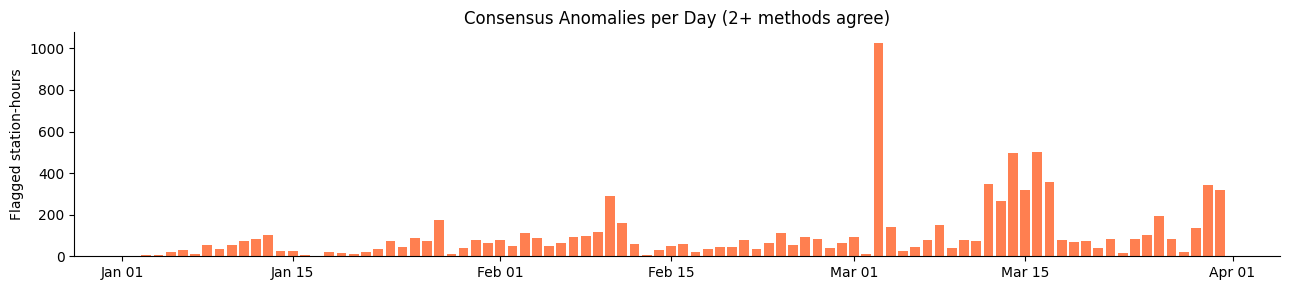

In [12]:
# Anomalies by day — are there event spikes?
daily_consensus = (
    flags[flags['consensus_anomaly']]
    .groupby(flags.loc[flags['consensus_anomaly'], 'hour'].dt.date)
    .size()
    .rename('consensus_anomalies')
)
daily_consensus.index = pd.to_datetime(daily_consensus.index)

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(daily_consensus.index, daily_consensus.values, color='coral', width=0.8)
ax.set_title('Consensus Anomalies per Day (2+ methods agree)')
ax.set_ylabel('Flagged station-hours')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

In [13]:
# Top anomalous station-hours by consensus
top = (
    flags[flags['consensus_anomaly']]
    .sort_values('trip_count', ascending=False)
    [['station_id', 'hour', 'trip_count', 'n_methods']]
    .head(15)
)
print('Top consensus anomalies (highest demand spikes):')
print(top.to_string(index=False))

Top consensus anomalies (highest demand spikes):
station_id                hour  trip_count n_methods
   5329.03 2024-03-14 17:00:00          99         3
   5470.12 2024-01-23 17:00:00          93         2
   5329.03 2024-03-14 18:00:00          90         3
   6584.12 2024-03-14 17:00:00          90         2
   5470.12 2024-03-13 17:00:00          87         2
   5470.12 2024-03-14 17:00:00          87         2
   6173.08 2024-03-12 17:00:00          85         2
   7141.07 2024-03-16 15:00:00          85         3
   5470.12 2024-03-26 17:00:00          84         2
   6173.08 2024-03-14 17:00:00          84         2
   6173.08 2024-03-14 18:00:00          83         2
   5470.12 2024-01-30 17:00:00          82         2
   5470.12 2024-02-26 17:00:00          82         2
   6822.09 2024-03-26 17:00:00          80         2
   6822.09 2024-03-14 17:00:00          80         2


## 6. Save Anomaly Labels

In [14]:
out = PROCESSED_DIR / 'anomaly_flags_2024Q1.parquet'
flags.to_parquet(out, index=False)
print(f'Saved anomaly flags → {out}  ({len(flags):,} rows)')
print(f'Consensus anomaly rate: {flags["consensus_anomaly"].mean()*100:.3f}%')

Saved anomaly flags → ..\data\processed\anomaly_flags_2024Q1.parquet  (1,963,864 rows)
Consensus anomaly rate: 0.465%


## 7. Key Findings

*(Fill in after running)*

- Z-score and IQR catch mostly the same spikes; IF catches subtler multivariate outliers
- Consensus anomalies (2+ methods) are the most trustworthy flags
- Anomaly spikes cluster on specific days → likely events (NYE, snowstorms, etc.)
- Low-activity cluster has higher anomaly rate — sparse demand makes any activity look anomalous
- Flagged rows will be excluded from A/B simulation baselines in Phase 5

→ **Next:** `05_ab_testing.ipynb`